# Homework 3 (due Friday, July 31st)
This assignment is designed to be practice outside of in-class lab.

There are only two problems this time. Do both for full credit. Reach out with any questions!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize

### Problem 1
There is a new data set in the `Datasets` folder on GitHub called `housing.csv`. This dataset is a collection of information on houses in the Portland/Vancouver area (if you plot the latitude and longitude you can see the outline of the coast!).
1. Load the `housing.csv` dataset from GitHub into your notebook (can be found: [here](https://github.com/garrett-kepler/Math-300----Mathematical-Computing/tree/main/Datasets))

2. Using `numpy`, built-in dataframe features, or functions you made in-lab, find the following for each column:
    - Median
    - Mean
    - Mode
    - Standard Deviation
    - Variance
    - Mean Absolute Deviation
3. Plot the `price` against `sqft_living`. Do you see a relationship?
4. Calculate the correlation between `price` against `sqft_living`. What does this value mean? Does it align with your answer to 3?
5. Perform linear regression on `price` against `sqft_living`. Plot the regression line and data on the same plot.
6. Compute your $R^2$ statistic for the regression line.

In [2]:
#1
url = "https://raw.githubusercontent.com/garrett-kepler/Math-300----Mathematical-Computing/main/Datasets/housing.csv"
housing = pd.read_csv(url)

In [3]:
#2
numeric = housing.select_dtypes(include=np.number)
print("Summary Statistics\n")
for col in numeric.columns:
    print(f"Column: {col}")
    print(f"Mean: {numeric[col].mean()}")
    print(f"Median: {numeric[col].median()}")
    mode = numeric[col].mode()
    if len(mode) > 0:
        print(f"Mode: {mode.iloc[0]}")
    else:
        print("Mode: None")
    print(f"Standard Deviation: {numeric[col].std()}")
    print(f"Variance: {numeric[col].var()}")
    print(f"Mean Absolute Deviation: {numeric[col].mad() if hasattr(numeric[col],'mad') else np.mean(np.abs(numeric[col]-numeric[col].mean()))}")
    print("-"*50)

Summary Statistics

Column: id
Mean: 4208924723.399
Median: 3746250655.0
Mode: 3528000040
Standard Deviation: 2843538109.43423
Variance: 8.085708979804793e+18
Mean Absolute Deviation: 2392648989.5008006
--------------------------------------------------
Column: price
Mean: 1740476.598
Median: 1531250.0
Mode: 1250000
Standard Deviation: 667345.1298067635
Variance: 445349522276.806
Mean Absolute Deviation: 443594.91210400005
--------------------------------------------------
Column: bedrooms
Mean: 4.115
Median: 4.0
Mode: 4
Standard Deviation: 0.920120438650088
Variance: 0.8466216216216303
Mean Absolute Deviation: 0.64622
--------------------------------------------------
Column: bathrooms
Mean: 3.282
Median: 3.25
Mode: 3.5
Standard Deviation: 0.9015479958320494
Variance: 0.8127887887887849
Mean Absolute Deviation: 0.6779680000000001
--------------------------------------------------
Column: sqft_living
Mean: 4006.934
Median: 3835.5
Mode: 3440
Standard Deviation: 1247.718554496661
Varianc

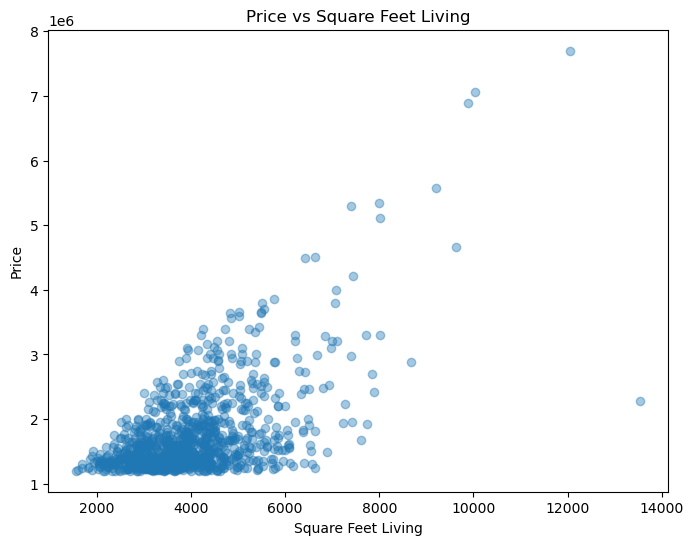

Correlation: 0.5794233888311174

Interpretation:
The correlation coefficient ranges from -1 to 1.
A value close to 1 indicates a strong positive linear relationship.



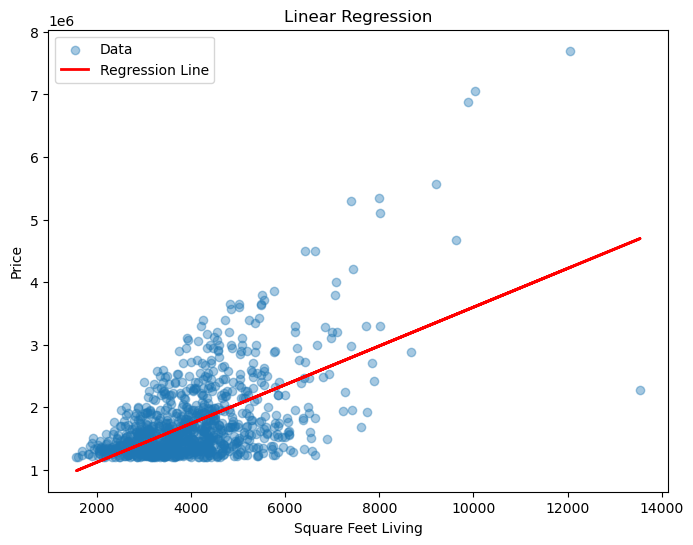

Slope: 309.9059280949559
Intercept: 498703.99791476654
R^2: 0.33573146352452987


In [5]:
#3
plt.figure(figsize=(8,6))
plt.scatter(housing["sqft_living"], housing["price"], alpha=0.4)
plt.xlabel("Square Feet Living")
plt.ylabel("Price")
plt.title("Price vs Square Feet Living")
plt.show()
corr = housing["price"].corr(housing["sqft_living"])
print("Correlation:", corr)
print("""
Interpretation:
The correlation coefficient ranges from -1 to 1.
A value close to 1 indicates a strong positive linear relationship.
""")
m, b = np.polyfit(housing["sqft_living"], housing["price"], 1)
x = housing["sqft_living"]
y = housing["price"]
y_pred = m*x + b
plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.4, label="Data")
plt.plot(x, y_pred, color="red", linewidth=2, label="Regression Line")
plt.xlabel("Square Feet Living")
plt.ylabel("Price")
plt.title("Linear Regression")
plt.legend()
plt.show()
SS_res = np.sum((y - y_pred)**2)
SS_tot = np.sum((y - np.mean(y))**2)
R2 = 1 - SS_res/SS_tot
print("Slope:", m)
print("Intercept:", b)
print("R^2:", R2)

There is a strong positive relation

Strong linear relationship

### Problem 2
Recall the following result we discussed in Week 5 Day 5 Lab:

- Let $A$ be a symmetric matrix ($A=A^T$). Let $R(A)=\frac{x^TAx}{x^Tx}$. Then, $\min\limits_{x\neq 0}R(A)=\lambda_{\min}(A)$ and $\max\limits_{x\neq 0}R(A)=\lambda_{\max}(A)$. Also, $x$'s that acheive these values are the eigenvectors.

Write a function that takes as an input a 2 by 2 matrix $A$, finds $\min\limits_{x\neq 0}R(A)$ and $\max\limits_{x\neq 0}R(A)$ using `scipy.optimize`, then outputs $|\lambda_{\min}(A)-\min\limits_{x\neq 0}R(A)|$ and $|\lambda_{\max}-\max\limits_{x\neq 0}R(A)|$ where the eigenvalues are calculated using `numpy`.

In [7]:
def rayleigh_errors(A):
    A = np.array(A, dtype=float)
    if not np.allclose(A, A.T):
        raise ValueError("Matrix must be symmetric.")
    def R(x):
        x = np.array(x)
        if np.linalg.norm(x) < 1e-10:
            return 1e20
        return (x.T @ A @ x) / (x.T @ x)
    x0 = np.array([1.0, 1.0])
    min_result = minimize(R, x0)
    max_result = minimize(lambda x: -R(x), x0)
    Rmin = min_result.fun
    Rmax = -max_result.fun
    eigvals = np.linalg.eigvalsh(A)
    lambda_min = np.min(eigvals)
    lambda_max = np.max(eigvals)
    err_min = abs(lambda_min - Rmin)
    err_max = abs(lambda_max - Rmax)
    return err_min, err_max
A = np.array([[2,1],
              [1,3]])
err_min, err_max = rayleigh_errors(A)
print("Minimum error:", err_min)
print("Maximum error:", err_max)

AttributeError: module 'numpy.linalg' has no attribute 'corm'